In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

In [2]:
# 1. Carrega o dataset S&P 500 (Kaggle: camnugent/sandp500)
df = pd.read_csv("all_stocks_5yr.csv", parse_dates=["date"])

# 2. Filtra apenas as linhas da Apple (AAPL) e ordena por data
aapl = df[df["Name"] == "AAPL"].sort_values("date").reset_index(drop=True)

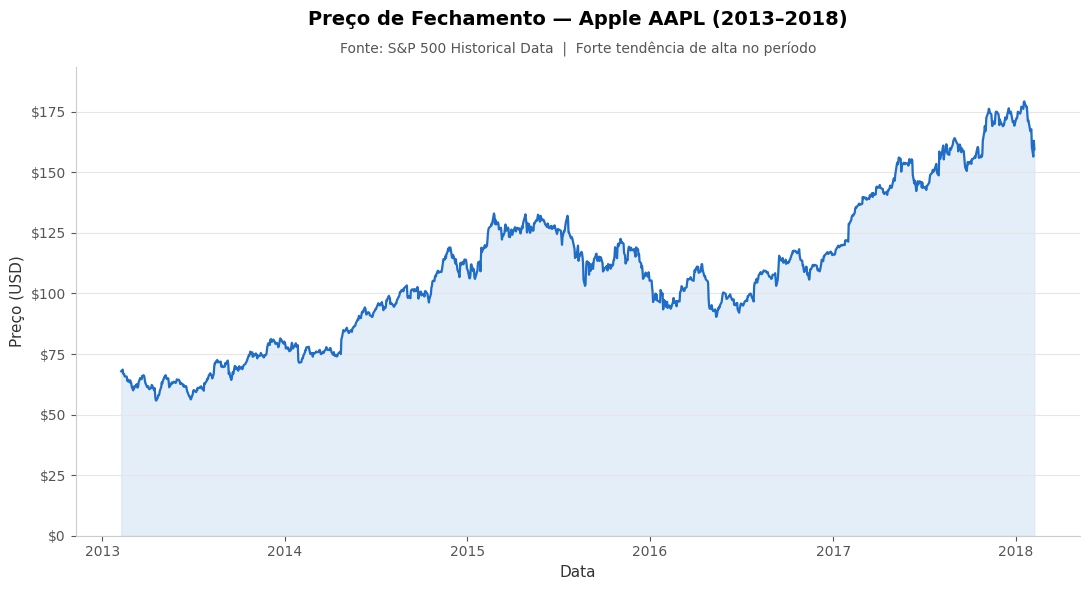

In [3]:
# 3. Cria a figura
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 4. Linha azul + área sombreada por baixo (estilo "area chart")
LINE = "#1f6dc7"
FILL = "#cfe1f3"
ax.plot(aapl["date"], aapl["close"], color=LINE, linewidth=1.6)
ax.fill_between(aapl["date"], aapl["close"], 0, color=FILL, alpha=0.55)

# 5. Título principal + subtítulo (como na imagem de referência)
ax.set_title(
    "Preço de Fechamento — Apple AAPL (2013–2018)",
    fontsize=14,
    fontweight="bold",
    loc="center",
    pad=30,
)
ax.text(
    0.5,
    1.02,
    "Fonte: S&P 500 Historical Data  |  Forte tendência de alta no período",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

# 6. Labels dos eixos
ax.set_xlabel("Data", fontsize=11, color="#333333")
ax.set_ylabel("Preço (USD)", fontsize=11, color="#333333")

# 7. Eixo Y começa em 0 e mostra valores em formato $
ax.set_ylim(0, aapl["close"].max() * 1.08)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# 8. Eixo X com marcação anual
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 9. Estética final — bordas e grade discretas
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax.tick_params(colors="#555555")

plt.tight_layout()
plt.savefig("aapl_2013_2018.png", dpi=1000, bbox_inches="tight")
plt.show()